# LAB 2: Linear Equations and Matrix Algebra

In this lab you will use python to study the following topics:

- Solving a system of linear equations by using the reduced row echelon form of the augmented matrix of the system.

- Forming linear combinations of a set of vectors and the fundamental concepts of linear independence.

- Matrix multiplication and its properties.

# First: you should run this cell

In [2]:
# Make all numpy available via shorter 'np' prefix
import numpy as np
# Make all sympy available via shorter 'sym' prefix
import sympy as sym


# matplotlib library
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator


def rvect(m):
    return np.fix((10 * (np.random.rand(m, 1))))


def rmat(m, n):
    return np.fix((10 * (np.random.rand(m, n))))


def rref(A):
    return np.array(sym.Matrix(A).rref(iszerofunc=lambda x:sym.comp(x,0,1e-13))[0], np.float64)


def nulbasis(A):
    A = sym.Matrix(A)
    tmp =  A.nullspace()
    n = len(tmp)
    m = len(tmp[0])
    N = np.zeros((m,n))
    for i in range(m):
        for j in range(n):
                N[i,j] = tmp[j][i] 
    return N

# Question 1. Solving Ax = b

In this question you will find the general solution $x \in R^3$ to a linear system $Ax = b$ of 3 equations in 5
variables $x_1, x_2, x_3, x_4, x_5$. Here $A$ is the $3 \times 5$ coeffient matrix system $b \in R^3$ is the given right-hand side of the system

<h4> 
    (a) Use rmat function that was defined in the first cell to generate a random $3 \times5$ integer matrix $A$ and to check that columns 1, 2, 3 of $A$ are the pivot columns.
</h4>

- `A = rmat(3, 5)`
- `np.linalg.matrix_rank(A[:, 0:3])`


In [ ]:
#Generates a 3x5 random matrix
#Max rank cant exceed the min of rows or cols whichever is smaller 
#The output is 3 because there are 3 lineraly independent cols 
#The other 2 are linear combination of the others 

np.random.seed(42)

A = rmat(3, 5)
print("----------A-----------")
print(A)
print("---------------------")

rank_A = np.linalg.matrix_rank(A[:, 0:3])

print("----------rank(A)-----")
print(rank_A)
print("---------------------")


----------A-----------
[[6. 3. 7. 4. 6.]
 [9. 2. 6. 7. 4.]
 [3. 7. 7. 2. 5.]]
---------------------
----------rank(A)-----
3
---------------------


In [2]:
#type your code here:


----------A-----------
[[9. 9. 2. 1. 7.]
 [7. 9. 6. 9. 3.]
 [1. 9. 0. 0. 4.]]
---------------------
----------rank(A)-----
3
---------------------


Note the use of the colon operator to select columns 1, 2, 3 of $A$. If the rank is less than 3, generate a new A
(this is unlikely, but it can happen). Include all the matrices that you generate this way in your lab report.
<h4>
When you have an $A$ for which the rank of the first three columns is 3:
</h4>

- Generate a random vector $b \in R^3$

- The reduced row echelon form R of the augmented matrix $\begin{bmatrix} A & b   \end{bmatrix}$:


In [ ]:
#So here im just checking the first 3 cols to see if their rank is less 
#Than 3 or not , if they are the system could behave diffrently 
#to avoid this we generate to matrix in R^3 space and have rank 3 

A_list = []

while True:
    A = rmat(3, 5)
    A_list.append(A)
    if np.linalg.matrix_rank(A[:, 0:3]) == 3:
        break

print("All generated matrices A:")
for i, A_mat in enumerate(A_list, start=1):
    print(f"\nA_{i} =")
    print(A_mat)

print("\nAccepted matrix A:")
print(A)

b = np.random.randint(1, 10, size=(3, 1))
print("\nVector b:")
print(b)

#entire system in 1 matrix
Ab = np.hstack((A, b))
print("\nAugmented matrix [A | b]:")
print(Ab)

Ab_sym = sp.Matrix(Ab)
R, pivots = Ab_sym.rref()

print("\nReduced Row Echelon Form of [A | b]:")
sp.pprint(R)

print("\nPivot columns")
print(pivots)


All generated matrices A:

A_1 =
[[7. 4. 5. 6. 2.]
 [2. 5. 4. 5. 0.]
 [2. 4. 6. 6. 1.]]

Accepted matrix A:
[[7. 4. 5. 6. 2.]
 [2. 5. 4. 5. 0.]
 [2. 4. 6. 6. 1.]]

Vector b:
[[4]
 [5]
 [3]]

Augmented matrix [A | b]:
[[7. 4. 5. 6. 2. 4.]
 [2. 5. 4. 5. 0. 5.]
 [2. 4. 6. 6. 1. 3.]]

Reduced Row Echelon Form of [A | b]:
⎡1  0  0  0.138888888888889  0.263888888888889   0.125 ⎤
⎢                                                      ⎥
⎢0  1  0  0.388888888888889  -0.361111111111111   1.25 ⎥
⎢                                                      ⎥
⎣0  0  1  0.694444444444444  0.319444444444444   -0.375⎦

Pivot columns
(0, 1, 2)


In [3]:
import sympy as sp

# Given matrix A
A = np.array([
    [9., 9., 2., 1., 7.],
    [7., 9., 6., 9., 3.],
    [1., 9., 0., 0., 4.]
])

# Given vector b
b = np.array([
    [5.],
    [8.],
    [2.]
])

print("-------b--------")
print(b)

augmented_matrix = np.hstack((A, b))

print("-------augmented_matrix---------")
print(augmented_matrix)
print("----------------")

aug_sym = sp.Matrix(augmented_matrix)
R, pivots = aug_sym.rref()

print("-------R------------------------------------------")
print(np.array(R, dtype=float))
print("--------------------------------------------------")


-------b--------
[[5.]
 [8.]
 [2.]]
-------augmented_matrix---------
[[9. 9. 2. 1. 7. 5.]
 [7. 9. 6. 9. 3. 8.]
 [1. 9. 0. 0. 4. 2.]]
----------------
-------R------------------------------------------
[[ 1.          0.          0.         -0.33333333  0.55555556  0.16666667]
 [ 0.          1.          0.          0.03703704  0.38271605  0.2037037 ]
 [ 0.          0.          1.          1.83333333 -0.72222222  0.83333333]]
--------------------------------------------------


In [3]:
#type your code here:


-------b--------
[[5.]
 [8.]
 [2.]]
----------------
-------augmented_matrix---------
[[9. 9. 2. 1. 7. 5.]
 [7. 9. 6. 9. 3. 8.]
 [1. 9. 0. 0. 4. 2.]]
----------------
-------R------------------------------------------
[[ 1.          0.          0.         -0.33333333  0.55555556  0.16666667]
 [ 0.          1.          0.          0.03703704  0.38271605  0.2037037 ]
 [ 0.          0.          1.          1.83333333 -0.72222222  0.83333333]]
--------------------------------------------------


<h4>
     To get the reduced row echelon form S = rref(A) just remove the last column from R:
</h4>

- `S = R[:, :-1] or R[:, 0:5]`


In [ ]:
Ab = np.hstack((A, b))
S = R[:, :-1]   
#we jsut want the rref matrix without the b
print("--------S------------")
print(S)
print("---------------------")


--------S------------
[[ 1.          0.          0.         -0.33333333  0.55555556]
 [ 0.          1.          0.          0.03703704  0.38271605]
 [ 0.          0.          1.          1.83333333 -0.72222222]]
---------------------


In [4]:
#type your code here:



--------S------------
[[ 1.          0.          0.         -0.33333333  0.55555556]
 [ 0.          1.          0.          0.03703704  0.38271605]
 [ 0.          0.          1.          1.83333333 -0.72222222]]
---------------------


(Note the use of the colon operator to select columns 1 to 5 of R).
<h4>Check by python that S = rref(A)</h4>

In [ ]:
#used built in function and gave the same results 
Ab = np.hstack((A, b))
Ab_sym = sp.Matrix(Ab)
R, _ = Ab_sym.rref()
R = np.array(R, dtype=float)

S = R[:, 0:5]

A_sym = sp.Matrix(A)
A_rref, _ = A_sym.rref()
A_rref = np.array(A_rref, dtype=float)

# Print rref(A)
print("--------rref(A)------------")
print(A_rref)
print("---------------------")
#np.closeall chks if 2 matrices are equal be fare2 baset 

--------rref(A)------------
[[ 1.          0.          0.         -0.33333333  0.55555556]
 [ 0.          1.          0.          0.03703704  0.38271605]
 [ 0.          0.          1.          1.83333333 -0.72222222]]
---------------------


In [5]:
#type your code here:


--------rref(A)------------
[[ 1.          0.          0.         -0.33333333  0.55555556]
 [ 0.          1.          0.          0.03703704  0.38271605]
 [ 0.          0.          1.          1.83333333 -0.72222222]]
---------------------


1. Which columns of $S$ are the pivot columns?

2. What is the rank of $R$ and the rank of $A$?

3. What is the nullity of $A$ and which variables $x_i$ are be the free variables?

4. Why does the equation $Ax = b$ have a solution?


In [ ]:
# Ans:
# 1-columns 1,2,3 
# 2-Rank = number of pivots cols = 3
# 3-Number of cols - rank = 5-3 = 2 , linearly dependent cols
# 4-Because rank(A) = rank(R) = 3 , which shows that the system has atleast 1 solution and is consistent
#Notes : 
# If rank(A) = rank([A|b]) then system is consistent so at least one solution exists.
# If rank(A) < rank([A|b]) then system is inconsistent so  no solution.
# If rank(A) < number of variables then some variables are free so infinitely many solutions.


#### Print the rank of A, R, and S matrices

In [ ]:
rank_A = np.linalg.matrix_rank(A)
rank_R = np.linalg.matrix_rank(R)
rank_S = np.linalg.matrix_rank(S)

print("Rank A :", rank_A)
print("Rank R :", rank_R)
print("Rank S :", rank_S)

Rank A : 3
Rank R : 3
Rank S : 3


In [6]:
#type your code here:


3
---------------------
3
---------------------
3
---------------------


#### (b) Use python to obtain (the last column of $R$), `c = R[:, [-1]]`. set `x = np.block([[c], [0], [0]])`. $x \in R^5$ and the last two components of $x$ are zeros. then:


- Calculate by python that $Ax - b = 0$ and $Sx - c = 0$.




In [ ]:
#Linearly independent cols = dependent variables 
#Linearly dependent cols = free variables 
#Here we're trying to see if Ax-b =0 to chk of ax=b
#S is the coof matrix and C is the right hand side of the equation 
S = R[:, :-1]
c = R[:, [-1]]
print("-----------c--------------")
print(c)
print("-------------------------")
#Here i made the first 3 cols c1,c2,c3 with their values and the rest = 0s
x = np.block([[c], [0], [0]])
print("-----------x--------------")
print(x)
print("-------------------------")
#Proves that the row reduced doesn't change the solution set of a system
Ax_minus_b = A @ x - b
print("--------A @ x - b--------------")
print(Ax_minus_b)
print("-------------------------")
#If that prints out 0s this means that it satifies the row-reduced system 
Sx_minus_c = S @ x - c
print("--------S @ x - c--------------")
print(Sx_minus_c)
print("-------------------------")

-----------c--------------
[[0.16666667]
 [0.2037037 ]
 [0.83333333]]
-------------------------
-----------x--------------
[[0.16666667]
 [0.2037037 ]
 [0.83333333]
 [0.        ]
 [0.        ]]
-------------------------
--------A @ x - b--------------
[[ 0.0000000e+00]
 [-8.8817842e-16]
 [ 0.0000000e+00]]
-------------------------
--------S @ x - c--------------
[[0.]
 [0.]
 [0.]]
-------------------------


In [7]:
#type your code here:


-----------c--------------
[[0.16666667]
 [0.2037037 ]
 [0.83333333]]
-------------------------
-----------x--------------
[[0.16666667]
 [0.2037037 ]
 [0.83333333]
 [0.        ]
 [0.        ]]
-------------------------
--------A @ x - b--------------
[[0.]
 [0.]
 [0.]]
-------------------------
--------A @ x - c--------------
[[0.]
 [0.]
 [0.]]
-------------------------


#### (c) Use python to calculate

- `u = np.block([[-S[:, [3]]], [1], [0]])`
- `v = np.block([[-S[:, [4]]], [0], [1]])`


1. Give a handwritten explanation, using symbols and linear algebra, rather than numbers, to show why u and v are the vectors that appear in the vector form of the general solution to Ax = 0.
    - Confirm by calculating `S @ u`, `A @ u`, `S @ v`, `A @ v`. You should get vectors that are (approximately) zero.
    - Now generate a random linear combination of u and v by the commands `s = np.random.rand(1)`, `t = np.random.rand(1)`, and `y = s * u + t * v` (Note that each occurrence of np.random.rand(1) generates a different random coefficient).

2. What properties of matrix and vector algebra ensure that Ay = 0?
    - Confirm by a python calculation that `A @ y` is approximately zero. 







In [ ]:
S = R[:, :-1]
#We've generated u and v in order to get the direction of the x4,x5
#Since they are free variables i dont care about their value i just want to 
#get their direction
#inorder to tell us how we move and still stay in the solution set
# u corresponds to free variable x4 = 1, x5 = 0
u = np.block([[-S[:, [3]]], [1.], [0.]])
print("-----------u-----------")
print(u)
print("----------------------")

# v corresponds to free variable x5 = 1, x4 = 0
v = np.block([[-S[:, [4]]], [0.], [1.]])
print("-----------v-----------")
print(v)
print("----------------------")

# Confirm S @ u = 0, A @ u ≈ 0
print("-----------S @ u-----------")
print(S @ u)
print("----------------------")

print("----------A @ u------------")
print(A @ u)
print("----------------------")

# Confirm S @ v = 0, A @ v ≈ 0
print("----------S @ v------------")
print(S @ v)
print("----------------------")

print("----------A @ v------------")
print(A @ v)
print("----------------------")

s = np.random.rand(1)
t = np.random.rand(1)


y = s * u + t * v
print("----------A @ y------------")
print(A @ y)
print("----------------------")

-----------u-----------
[[-0.13888889]
 [-0.38888889]
 [-0.69444444]
 [ 1.        ]
 [ 0.        ]]
----------------------
-----------v-----------
[[-0.26388889]
 [ 0.36111111]
 [-0.31944444]
 [ 0.        ]
 [ 1.        ]]
----------------------
-----------S @ u-----------
[[0.]
 [0.]
 [0.]]
----------------------
----------A @ u------------
[[0.0000000e+00]
 [0.0000000e+00]
 [8.8817842e-16]]
----------------------
----------S @ v------------
[[0.]
 [0.]
 [0.]]
----------------------
----------A @ v------------
[[0.00000000e+00]
 [2.22044605e-16]
 [2.22044605e-16]]
----------------------
----------A @ y------------
[[6.66133815e-16]
 [0.00000000e+00]
 [7.77156117e-16]]
----------------------


In [8]:
#type your code here:


-----------u-----------
[[ 0.33333333]
 [-0.03703704]
 [-1.83333333]
 [ 1.        ]
 [ 0.        ]]
----------------------
-----------v-----------
[[-0.55555556]
 [-0.38271605]
 [ 0.72222222]
 [ 0.        ]
 [ 1.        ]]
----------------------
-----------S @ u-----------
[[0.]
 [0.]
 [0.]]
----------------------
----------A @ u------------
[[ 0.00000000e+00]
 [-2.22044605e-16]
 [ 0.00000000e+00]]
----------------------
----------S @ v------------
[[0.]
 [0.]
 [0.]]
----------------------
----------A @ v------------
[[ 2.22044605e-16]
 [-8.88178420e-16]
 [ 4.44089210e-16]]
----------------------
---------A @ y-------------
[[1.11022302e-16]
 [5.55111512e-16]
 [2.22044605e-16]]
----------------------


#### (d) Use python to calculate `z = x + y` .
- What properties of matrix and vector algebra imply that $Az = b$?
- Confirm by a python calculation that `A @ z - b` is approximately zero.

In [ ]:
#Ay=b is the null space 
#Ax=b is the solution itself
#adding them together y and x j, helps getting all solutions in a space
#since that y gets the directions or how to move in the space 
#and x gets the points to exact solutions 
#in order to show that it actually works 
#z=x+y if it is = 0 then z satifies the system
z = x + y

Az_minus_b = np.round(A @ z - b, decimals=10) 
print("-----------A @ z - b--------------")
print(Az_minus_b)
print("----------------------------------")

-----------A @ z - b--------------
[[-0.]
 [ 0.]
 [ 0.]]
----------------------------------


In [9]:
#type your code here:



-----------A @ z - b--------------
[[0.]
 [0.]
 [0.]]
----------------------------------


# Question 2. Spanning Sets and Linear Independence

#### Generate four random vectors in R3 by the command
- `u1 = rvect(3)`
- `u2 = rvect(3)`
- `u3 = rvect(3)`
- `u4 = rvect(3)`




#### (a) Consider the set of vectors S = {u1, u2, u3}. To determine whether S is linearly independent, form the matrix A with the vectors from S as columns and calculate its reduced row echelon form
- `A = np.block([u1, u2, u3])`
- `rref(A)`

#### Use these calculations to answer the following questions:

1. How many free variables does the equation Ax = 0 have?

2. Is the set S linearly independent or linearly dependent? Why?

In [ ]:
u1 = np.random.randint(0, 10, size=(3, 1))
u2 = np.random.randint(0, 10, size=(3, 1))
u3 = np.random.randint(0, 10, size=(3, 1))

A = np.hstack([u1, u2, u3]) #generted a matix from those vectors 
print("------A---------")
print(A)
print("----------------")

#getting rref in order to get the columns and free variables 
A_sym = sp.Matrix(A)
R, _ = A_sym.rref()
R = np.array(R, dtype=float)

print("------rref(A)---------")
print(R)
print("----------------")

#based on the output all 3 cols are pivot cols 
#no free variables 
#so this means that u1 , u2 , u3 are linearly independent 
#here it covers the whole space

------A---------
[[0 6 9]
 [2 8 6]
 [1 1 1]]
----------------
------rref(A)---------
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
----------------


In [10]:
####type your code here:



------A---------
[[0. 3. 3.]
 [2. 7. 2.]
 [8. 0. 0.]]
----------------
------rref(A)---------
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
----------------


#### (b) Consider the set of vectors T = {u1, u2, u3, u4}. To determine whether T is linearly independent, form the matrix B with the vectors from T as columns and calculate its reduced row echelon form:

- `B = [u1 u2 u3 u4]`
- `rref(B)`

#### Use these calculations to answer the following questions:

1. How many free variables does the equation $Bx = 0$ have?

2. Is the set T linearly independent or linearly dependent?

In [ ]:
# There are 4 columns and 3 pivot columns showing 
# 1 free variable in col 4
# Linearly dependent, because there is 1 free variable

In [14]:
u4 = np.random.randint(0, 10, size=(3, 1))

B = np.hstack([u1, u2, u3, u4])
print("------B---------")
print(B)
print("----------------")

B_sym = sp.Matrix(B)
R, _ = B_sym.rref()
R = np.array(R, dtype=float)

print("------rref(B)---------")
print(R)
print("----------------")


------B---------
[[0 6 9 6]
 [2 8 6 6]
 [1 1 1 3]]
----------------
------rref(B)---------
[[ 1.   0.   0.   2.6]
 [ 0.   1.   0.  -0.8]
 [ 0.   0.   1.   1.2]]
----------------


In [11]:
#type your code here:


------B---------
[[0. 3. 3. 1.]
 [2. 7. 2. 4.]
 [8. 0. 0. 2.]]
----------------
------rref(B)---------
[[ 1.          0.          0.          0.25      ]
 [ 0.          1.          0.          0.56666667]
 [ 0.          0.          1.         -0.23333333]]
----------------


#### (c) Let v be a random linear combination of u1 and u2:

- `v = np.random.rand(1) * u1 + np.random.rand(1) * u2`

#### Thus v is of the form c1u1 + c2u2 for some scalars c1, c2. Consider the set of vectors U = {u1, u2, v}.

1. Is the set U linearly independent or linearly dependent?
2. Answer first without calculation using the definition of linear independent sets.



#### Check your answer by python using the method of part (a).

In [ ]:
#They are linealy dependent since that v depends on
# u1 and u2 in generating it 
#so v is a combination of u1 and u2 


In [15]:
# Random linear combination v = c1*u1 + c2*u2
c1 = np.random.rand()
c2 = np.random.rand()

# random linear combination v = c1*u1 + c2*u2 as
# the rule in the question
v = c1 * u1 + c2 * u2

# Form matrix U with u1, u2, v as columns
U = np.hstack([u1, u2, v])
print("------U---------")
print(U)
print("----------------")

# Compute RREF of U
U_sym = sp.Matrix(U)
R, _ = U_sym.rref()
R = np.array(R, dtype=float)

print("------rref(U)---------")
print(R)
print("----------------")


------U---------
[[0.         6.         4.38150835]
 [2.         8.         6.78235058]
 [1.         1.         1.20042111]]
----------------
------rref(U)---------
[[1.         0.         0.47016972]
 [0.         1.         0.73025139]
 [0.         0.         0.        ]]
----------------


In [12]:
#type your code here:


------U---------
[[0.         3.         0.84174763]
 [2.         7.         2.81036291]
 [8.         0.         3.3851404 ]]
----------------
------rref(U)---------
[[1.         0.         0.42314255]
 [0.         1.         0.28058254]
 [0.         0.         0.        ]]
----------------


# Question 3 :Visualizing the Column Space

In this question you will determine visually whether given vectors lie in the column space of a matrix.
Random Seed: Initialize the random number generator by typing
rand(’seed’, abcd)
where abcd are the last four digits of your student ID number. This will ensure that you generate your own
particular random vectors and matrices.

#### Now generate a random $3 \times 2$ integer matrix $A$ by the python and calculate rank(A). Since $A$ is a random matrix, the rank is very likely to be 2. If the rank is not 2, generate another A. Repeat the test until you get a matrix with rank 2.

- `A = rmat(3, 2)`
- `np.linalg.matrix_rank(A)`


In [13]:
#type your code here:


------------A-------------
[[7. 8.]
 [5. 6.]
 [3. 8.]]
--------------------------
------------rank(A)-------------
2
--------------------------


#### Use this matrix in the rest of the question. If you need to generate more than one matrix, include all the matrices you generate in your lab report.

#### (a) Define `u = A[:,[0]]`, `v = A[:,[1]]` to be the column vectors for A. To graph the column space Col(A) of A, enter the python commands:
- `s, t = np.meshgrid(np.arange(-1, 1, 0.1), np.arange(-1, 1, 0.1))`
- `X = s * u[0] + t * v[0]`
- `Y = s * u[1] + t * v[1]`
- `Z = s * u[2] + t * v[2]`
- Use matplotlib to graph the cloumn space using `plot_surface` as in this [example](https://matplotlib.org/gallery/mplot3d/surface3d.html#sphx-glr-gallery-mplot3d-surface3d-py)
- Set graph axis limit -10, 10.
- Set the color map of the graph to `cm.hot`.

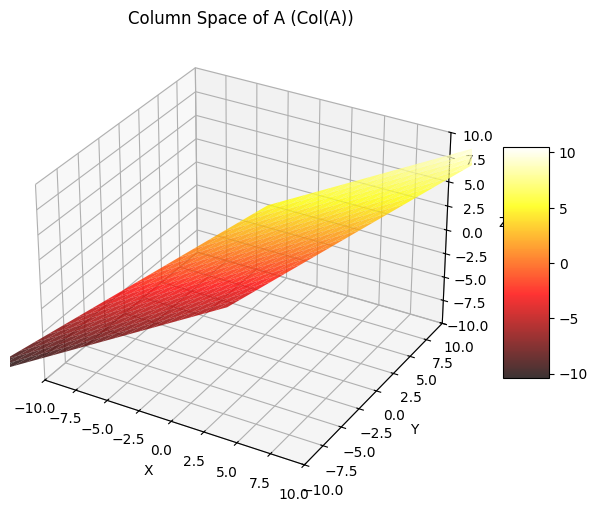

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Column vectors u and v from your output
u = np.array([[7],[5],[3]])
v = np.array([[8],[6],[8]])

# Create grid for linear combinations
s, t = np.meshgrid(np.arange(-1, 1.1, 0.1), np.arange(-1, 1.1, 0.1))

# Compute the plane points
X = s * u[0] + t * v[0]
Y = s * u[1] + t * v[1]
Z = s * u[2] + t * v[2]

# Plot the column space
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap=cm.hot, alpha=0.8)

# Set axis limits
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_zlim(-10, 10)

# Labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Column Space of A (Col(A))')

# Show color bar
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()
#bec the rank is 2 so the figure is plane


------------u-------------
[[7.]
 [5.]
 [3.]]
--------------------------
------------v-------------
[[8.]
 [6.]
 [8.]]
--------------------------


C:\Users\OMARME~1\AppData\Local\Temp/ipykernel_23816/3205482725.py:15: MatplotlibDeprecationWarning: Calling gca() with keyword arguments was deprecated in Matplotlib 3.4. Starting two minor releases later, gca() will take no keyword arguments. The gca() function should only be used to get the current axes, or if no axes exist, create new axes with default keyword arguments. To create a new axes with non-default arguments, use plt.axes() or plt.subplot().
  ax = fig.gca(projection='3d')


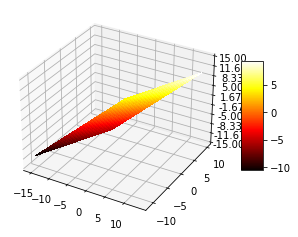

In [14]:
#type your code here


#### (b) Generate a random vector in R3 using the `rvect` function
- b = rvect(3)

In [17]:
b = rvect(3)

print("------------b-------------")
print(b)
print("--------------------------")


------------b-------------
[[5.]
 [4.]
 [6.]]
--------------------------


In [15]:
#type your code here:


------------b-------------
[[2.]
 [2.]
 [9.]]
--------------------------


#### To graph the line Span(b) in the same figure as Col(A):
- Copy the previous code that was used to graph Col(A)
- Generate array r. `r = np.arange(-1, 1, 0.05)`
- Plot the span(b). `ax.plot(r * b[0], r * b[1], r * b[2], 'b+', markersize=20)`
- Note that the previous step should be before plt.show() to plot on the same figure.
- Use `ax.view_init(45, 45)` change the values 45, 45 to rotate the figure to different view.

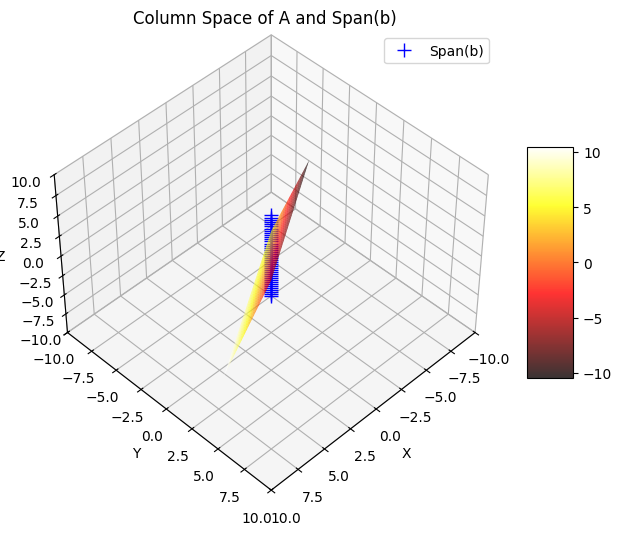

In [18]:

u = np.array([[7],[5],[3]])
v = np.array([[8],[6],[8]])

b = np.array([[2.],[2.],[9.]])

s, t = np.meshgrid(np.arange(-1, 1.1, 0.1), np.arange(-1, 1.1, 0.1))

# Linear combination of u and v to form the column space plane
X = s * u[0] + t * v[0]
Y = s * u[1] + t * v[1]
Z = s * u[2] + t * v[2]

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap=cm.hot, alpha=0.8)

r = np.arange(-1, 1, 0.05)
ax.plot(r * b[0], r * b[1], r * b[2], 'b+', markersize=10, label='Span(b)')

ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_zlim(-10, 10)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Column Space of A and Span(b)')

ax.view_init(45, 45)

fig.colorbar(surf, shrink=0.5, aspect=5)
ax.legend()

plt.show()


C:\Users\OMARME~1\AppData\Local\Temp/ipykernel_23816/2380683397.py:3: MatplotlibDeprecationWarning: Calling gca() with keyword arguments was deprecated in Matplotlib 3.4. Starting two minor releases later, gca() will take no keyword arguments. The gca() function should only be used to get the current axes, or if no axes exist, create new axes with default keyword arguments. To create a new axes with non-default arguments, use plt.axes() or plt.subplot().
  ax = fig.gca(projection='3d')


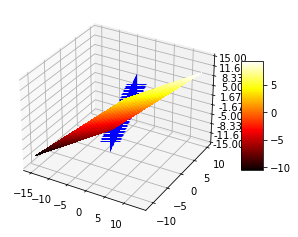

In [16]:
#type your code here:


#### (c) Can you find a vector $x \in R^2$ such that $Ax = b$, where $A$ is the matrix and $b$ is the vector that you have generated? Explain why or why not using the graph from part (b).


### -------------------------------------Type your answer here------------------------------------------------------------ ###



### ---------------------------------------------------------------------------------------------------------------------------------- ###

In [ ]:
#since vector b the blue part lies inside the 
#plane so the system of equations are right answer for martix a 


#### (d) Generate a random vector lying in Col(A) where:

- `z = np.random.rand(2, 1)`
- `c = A @ z`

In [20]:
#didnt understand what did we do here?
u = np.array([[7], [5], [3]])
v = np.array([[8], [6], [8]])

A = np.hstack([u, v])  

z = np.random.rand(2, 1)  

c = A @ z

print("---------c (vector in Col(A))-----------")
print(c)
print("----------------------------------------")


---------c (vector in Col(A))-----------
[[10.19729449]
 [ 7.53857406]
 [ 8.44694564]]
----------------------------------------


In [17]:
#type your code here:


---------c-------------
[[7.06252724]
 [5.23346768]
 [6.04768326]]
-----------------------


#### Plot a new graph of Span(c) and Col(A)

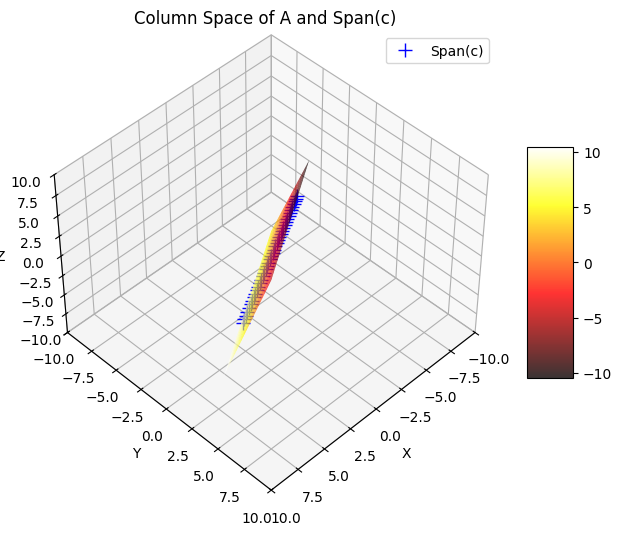

In [22]:
s, t = np.meshgrid(np.arange(-1, 1.1, 0.1), np.arange(-1, 1.1, 0.1))
X = s * u[0] + t * v[0]
Y = s * u[1] + t * v[1]
Z = s * u[2] + t * v[2]

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap=cm.hot, alpha=0.8)

r = np.arange(-1, 1, 0.05)
ax.plot(r * c[0], r * c[1], r * c[2], 'b+', markersize=10, label='Span(c)')

ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_zlim(-10, 10)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Column Space of A and Span(c)')

ax.view_init(45, 45)

fig.colorbar(surf, shrink=0.5, aspect=5)
ax.legend()

plt.show()


C:\Users\OMARME~1\AppData\Local\Temp/ipykernel_23816/3222810454.py:3: MatplotlibDeprecationWarning: Calling gca() with keyword arguments was deprecated in Matplotlib 3.4. Starting two minor releases later, gca() will take no keyword arguments. The gca() function should only be used to get the current axes, or if no axes exist, create new axes with default keyword arguments. To create a new axes with non-default arguments, use plt.axes() or plt.subplot().
  ax = fig.gca(projection='3d')


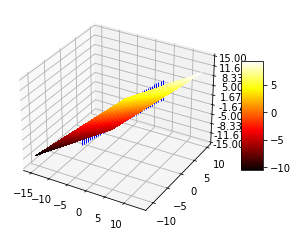

In [18]:
#type your code here


# Question 4: Reduced Row Echelon Form and Null Space

#### First generate a random $3 \times 3$ integer matrix $B$ and check its rank:
- `B = rmat(3, 3)`
- `np.linalg.matrix_rank(B)`

In [ ]:
import numpy as np
np.random.seed(42)

B = rmat(3, 3)

rank_B = np.linalg.matrix_rank(B)

print("-----------B---------------")
print(B)
print("--------------------------")
print("----------rank(B)------------")
print(rank_B)
print("--------------------------")


-----------B---------------
[[3. 9. 7.]
 [5. 1. 1.]
 [0. 8. 6.]]
--------------------------
----------rank(B)------------
3
--------------------------


In [19]:
#type your code here:


-----------B---------------
[[1. 8. 7.]
 [8. 8. 8.]
 [8. 0. 1.]]
--------------------------
----------rank(B)------------
3
--------------------------


#### Since $B$ is random, it is very likely to have rank $3$. If not, generate another $B$ until this is true. Now use $B$ to define a $3 \times 5$ matrix $A$ and its reduced row echelon form $R$ by

- `A = np.block([B[:, [0]], B[:, [1]], 2 * B[:, [0]] + 3 * B[:, [1]], 4 * B[:, [0]] - 5 * B[:, [1]], B[:, [2]]])`
- `R = rref(A)`

#### (a) Use the definition of $A$ in terms of $B$ and the Column Correspondence Property to answer the following.

- Explain why columns #1, #2, and #5 are the pivot columns of A and R.

In [ ]:
#1,2,5 are pivot columns because of the column correspondance property 
#which say that if there are cols which is a combination of previous 
#cols then they can't be pivot cols 
#since that cols 3,4 are generated based on some scalar value , multiplied by the the prev cols 
#then thye cant be pivot 
#and is clearly shown in the rref 

while True:
    B = rmat(3, 3)
    if np.linalg.matrix_rank(B) == 3:
        break
    
A = np.block([
    B[:, [0]],                
    B[:, [1]],               
    2*B[:, [0]] + 3*B[:, [1]],
    4*B[:, [0]] - 5*B[:, [1]], 
    B[:, [2]]                  
])

print("-----------A---------------")
print(A)
print("--------------------------")

A_sym = sp.Matrix(A)
R, _ = A_sym.rref()
R = np.array(R, dtype=float)

print("----------R------------")
print(R)
print("--------------------------")


-----------A---------------
[[  7.   0.  14.  28.   9.]
 [  8.   2.  22.  22.   1.]
 [  1.   3.  11. -11.   5.]]
--------------------------
----------R------------
[[ 1.  0.  2.  4.  0.]
 [ 0.  1.  3. -5.  0.]
 [ 0.  0.  0.  0.  1.]]
--------------------------


In [20]:
#type your code here:


-----------A---------------
[[  1.   8.  26. -36.   7.]
 [  8.   8.  40.  -8.   8.]
 [  8.   0.  16.  32.   1.]]
--------------------------
----------R------------
[[ 1.  0.  2.  4.  0.]
 [ 0.  1.  3. -5.  0.]
 [ 0.  0.  0.  0.  1.]]
--------------------------


#### (b) Let $V$ be the set of solutions to the homogeneous system of equations $Ax = 0$ (the null space of $A$). In the equation $Ax = 0$ (where $x \in R^5$), 

- what are the free variables and what is dim V ?

In [ ]:
#Free variables are x3,x4 
#Dimension of v is 2

#### (c) Use the python function that was defined in the first cell `nulbasis` to calculate the special solutions to the system of equations $Ax = 0$:

- `N = nulbasis(A)`

#### The columns of $N$ are the solutions to $Ax = 0$ obtained by setting one free variable to 1 and all the other free variables to 0. Define:
- `v1 = N[:,[0]]`
- `v2 = N[:,[1]]`

(Notice that `v1` and `v2` are 5-component vectors, not scalars.)

1. Which component of v1 is 1 and which components of v1 are zero?

2. Which component of v2 is 1 and which components of v2 are zero?

3. Check by python that v1 and v2 are in null space of A.

In [ ]:
#didnt understand ask about it 
N = nulbasis(A)
print("-------------N--------------")
print(N)

v1 = N[:, [0]]
v2 = N[:, [1]]
print("-------------v1--------------")
print(v1)
print("-------------v2--------------")
print(v2)

def check_components(v):
    ones = np.where(np.isclose(v, 1))[0] 
    zeros = np.where(np.isclose(v, 0))[0] 
    return ones, zeros

ones_v1, zeros_v1 = check_components(v1)
ones_v2, zeros_v2 = check_components(v2)

print(f"v1: component(s) = 1 -> {ones_v1 + 1}, component(s) = 0 -> {zeros_v1 + 1}")
print(f"v2: component(s) = 1 -> {ones_v2 + 1}, component(s) = 0 -> {zeros_v2 + 1}")

print("-------------A @ v1--------------")
print(A @ v1)
print("-------------A @ v2--------------")
print(A @ v2)

print("v1 in null space?", np.allclose(A @ v1, 0))
print("v2 in null space?", np.allclose(A @ v2, 0))


-------------N--------------
[[-2. -4.]
 [-3.  5.]
 [ 1.  0.]
 [ 0.  1.]
 [ 0.  0.]]
-------------v1--------------
[[-2.]
 [-3.]
 [ 1.]
 [ 0.]
 [ 0.]]
-------------v2--------------
[[-4.]
 [ 5.]
 [ 0.]
 [ 1.]
 [ 0.]]
v1: component(s) = 1 -> [3], component(s) = 0 -> [4 5]
v2: component(s) = 1 -> [4], component(s) = 0 -> [3 5]
-------------A @ v1--------------
[[0.]
 [0.]
 [0.]]
-------------A @ v2--------------
[[0.]
 [0.]
 [0.]]
v1 in null space? True
v2 in null space? True


In [21]:
#type your code here:


-------------N--------------
[[-2. -4.]
 [-3.  5.]
 [ 1.  0.]
 [ 0.  1.]
 [ 0.  0.]]
----------------------------
-------------v1--------------
[[-2.]
 [-3.]
 [ 1.]
 [ 0.]
 [ 0.]]
----------------------------
-------------v2--------------
[[-4.]
 [ 5.]
 [ 0.]
 [ 1.]
 [ 0.]]
----------------------------
-------------A @ v1--------------
[[0.]
 [0.]
 [0.]]
----------------------------
-------------A @ v2--------------
[[0.]
 [0.]
 [0.]]
----------------------------


#### (d) Now generate a random linear combination `x` of the vectors `v1` and `v2`:
- `s = np.random.rand(1)` 
- `t = np.random.rand(1)` 
- `x = s * v1 + t * v2`

(Note that each occurrence of rand(1) generates a different random coefficient).

- Confirm by python that $x$ satisfies $Ax = 0$ and $Rx = 0$.

In [ ]:
#didnt undertsand 

N = nulbasis(A)  
print("-------------N--------------")
print(N)

v1 = N[:, [0]]  
v2 = N[:, [1]]  
print("-------------v1--------------")
print(v1)
print("-------------v2--------------")
print(v2)


def check_components(v):
    ones = np.where(np.isclose(v, 1))[0] 
    zeros = np.where(np.isclose(v, 0))[0] 
    return ones, zeros

ones_v1, zeros_v1 = check_components(v1)
ones_v2, zeros_v2 = check_components(v2)

print(f"v1: component(s) = 1 -> {ones_v1 + 1}, component(s) = 0 -> {zeros_v1 + 1}")
print(f"v2: component(s) = 1 -> {ones_v2 + 1}, component(s) = 0 -> {zeros_v2 + 1}")

print("-------------A @ v1--------------")
print(A @ v1)
print("-------------A @ v2--------------")
print(A @ v2)

print("v1 in null space?", np.allclose(A @ v1, 0))
print("v2 in null space?", np.allclose(A @ v2, 0))

s = np.random.rand(1)
t = np.random.rand(1)

x = s * v1 + t * v2
print("Random coefficients: s =", s, ", t =", t)
print("Random linear combination x:\n", x)


print("-------------A @ x--------------")
print(A @ x)
print("x in null space of A?", np.allclose(A @ x, 0))

if 'R' in globals():  
    print("-------------R @ x--------------")
    print(R @ x)
    print("x in null space of R?", np.allclose(R @ x, 0))


-------------N--------------
[[-2. -4.]
 [-3.  5.]
 [ 1.  0.]
 [ 0.  1.]
 [ 0.  0.]]
-------------v1--------------
[[-2.]
 [-3.]
 [ 1.]
 [ 0.]
 [ 0.]]
-------------v2--------------
[[-4.]
 [ 5.]
 [ 0.]
 [ 1.]
 [ 0.]]
v1: component(s) = 1 -> [3], component(s) = 0 -> [4 5]
v2: component(s) = 1 -> [4], component(s) = 0 -> [3 5]
-------------A @ v1--------------
[[0.]
 [0.]
 [0.]]
-------------A @ v2--------------
[[0.]
 [0.]
 [0.]]
v1 in null space? True
v2 in null space? True
Random coefficients: s = [0.45049925] , t = [0.01326496]
Random linear combination x:
 [[-0.95405835]
 [-1.28517295]
 [ 0.45049925]
 [ 0.01326496]
 [ 0.        ]]
-------------A @ x--------------
[[1.77635684e-15]
 [4.44089210e-16]
 [1.77635684e-15]]
x in null space of A? True
-------------R @ x--------------
[[0.]
 [0.]
 [0.]]
x in null space of R? True


In [22]:
#type your code here:


-------------A @ x--------------
[[ 1.77635684e-15]
 [-7.10542736e-15]
 [ 0.00000000e+00]]
--------------------------------
-------------R @ x--------------
[[0.]
 [0.]
 [0.]]
--------------------------------
